## 1b · Static paths: four successful matched runs (2×2)
Four layouts where **both** agents reach the reward; each panel shows the
shared spawn (black dot), the reward (green star + reach circle), and both
agents' full paths. Uses the lightweight episode runner (no per-step
observations needed for a static plot).


In [14]:
from src.rl.traj_viz import run_matched_episode

def collect_double_successes(sides, n_wanted=4, tries=80, max_steps=200):
    """Sample shared layouts until n_wanted have BOTH agents reaching."""
    sampler = sides['vision'].arena
    keep = []
    for t in range(tries):
        pose, goal = sampler._sample_layout()
        eps = {name: run_matched_episode(side, pose, goal, max_steps,
                                         noise_offset=700_000 + t * 1000)
               for name, side in sides.items()}
        if all(ep['reached'] for ep in eps.values()):
            keep.append({'pose': np.array(pose), 'goal': np.array(goal), 'eps': eps})
            print(f'layout {t}: both reached '
                  + ', '.join(f"{n} in {ep['steps']}" for n, ep in eps.items()))
            if len(keep) == n_wanted:
                return keep
    print(f'only {len(keep)}/{n_wanted} double successes in {tries} tries')
    return keep

examples = collect_double_successes(sides, n_wanted=4)


layout 0: both reached vision in 29, audio in 22
layout 1: both reached vision in 17, audio in 36
layout 2: both reached vision in 25, audio in 31
layout 3: both reached vision in 21, audio in 23


saved runs/rl-armA-independent-v2/viz/paths_2x2.png and .svg


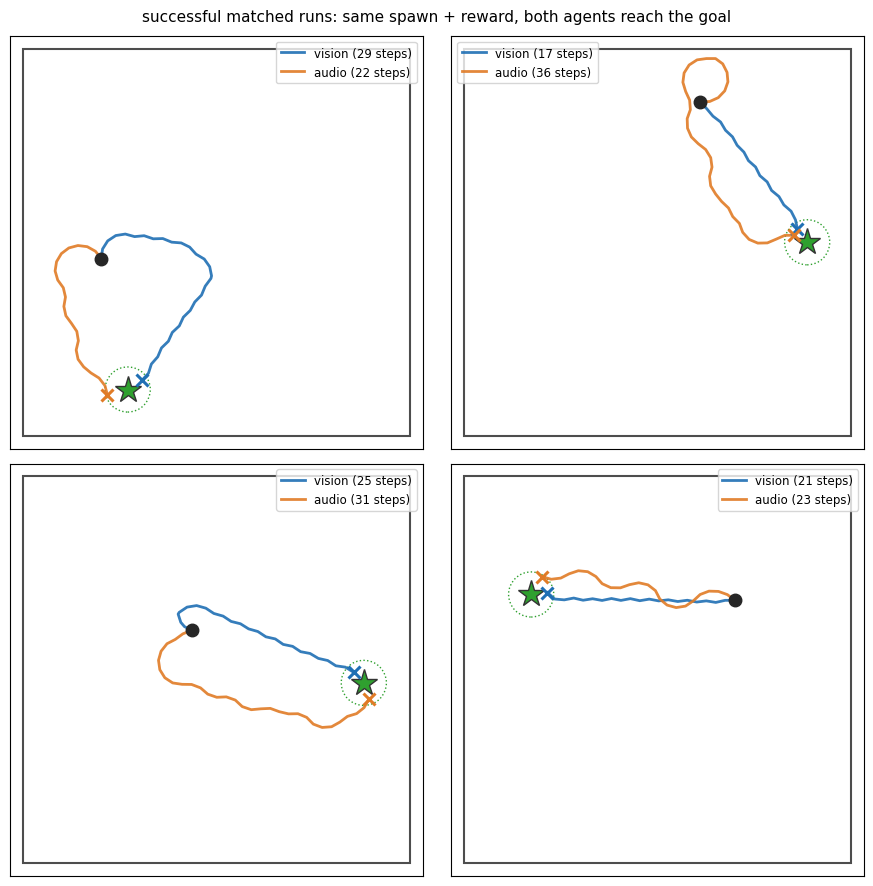

In [15]:
COLORS = {'vision': '#1f6fb4', 'audio': '#e07b26'}
h = arena_cfg.half_extent
fig, axes = plt.subplots(2, 2, figsize=(9, 9))
for ax, ex in zip(axes.ravel(), examples):
    ax.add_patch(plt.Rectangle((-h, -h), 2*h, 2*h, fill=False, lw=1.5, color='0.3'))
    ax.plot(*ex['goal'], marker='*', ms=20, color='#2fa02f', mec='0.2', zorder=5)
    ax.add_patch(plt.Circle(ex['goal'], arena_cfg.reach_threshold, fill=False,
                            ls=':', color='#2fa02f', lw=1.0))
    ax.plot(*ex['pose'][:2], marker='o', ms=9, color='0.15', zorder=6)
    for name, ep in ex['eps'].items():
        path = ep['path']
        ax.plot(path[:, 0], path[:, 1], '-', color=COLORS[name], lw=2.0,
                alpha=0.9, label=f"{name} ({ep['steps']} steps)")
        ax.plot(*path[-1], marker='x', ms=8, mew=2.2, color=COLORS[name], zorder=6)
    ax.legend(fontsize=8.5, loc='best')
    ax.set_xlim(-h-.2, h+.2); ax.set_ylim(-h-.2, h+.2)
    ax.set_aspect('equal'); ax.set_xticks([]); ax.set_yticks([])
for ax in axes.ravel()[len(examples):]:
    ax.axis('off')
fig.suptitle('successful matched runs: same spawn + reward, both agents reach the goal',
             fontsize=11)
fig.tight_layout()
fig.savefig(VIZ / 'paths_2x2.png', dpi=300, bbox_inches='tight')
fig.savefig(VIZ / 'paths_2x2.svg', bbox_inches='tight')
print('saved', VIZ / 'paths_2x2.png', 'and .svg')


# RL environment visualizations: navigation, cue fields, audio spectrograms

Run on **manitoulin** from the repo root (needs the run dirs + GL for MuJoCo
rendering — EGL is set below for headless use).

1. **Animated navigation** — one trained agent per modality walking from spawn to
   the reward, with what the agent sees at each step (camera / binaural log-mel).
2. **Cue heatmaps** — vision: measured green glow of the goal from every position;
   audio: analytic loudness & SNR fields from the sensor's own gain/noise model.
3. **Reward-cue spectrograms** — at the goal vs. far away.


In [ ]:
%load_ext autoreload
%autoreload 2
import os, sys
os.environ.setdefault('MUJOCO_GL', 'egl')          # headless GL on the server
from pathlib import Path
root = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'src').is_dir())
sys.path.insert(0, str(root)); sys.path.insert(0, str(root / 'scripts')); os.chdir(root)

import numpy as np, torch, yaml
import matplotlib.pyplot as plt
from matplotlib import animation
from IPython.display import HTML
from rl_train import build_sides                     # scripts/rl_train.py
from src.rl.arena import bearing, kinematic_step
from src.rl.cross_render import render_state
from src.utils import set_seed


## Load a trained run
Point `RUN_DIR` at any RL run; `CHECKPOINT` at `final.pt` or a `windowN.pt`.


In [ ]:
RUN_DIR = Path('runs/rl-armA-independent-v2')    # <-- pick your run
CHECKPOINT = 'final.pt'
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

cfg = yaml.safe_load((RUN_DIR / 'config.yaml').read_text())
set_seed(cfg['seed'])
sides = build_sides(cfg, DEVICE)
state = torch.load(RUN_DIR / CHECKPOINT, map_location='cpu', weights_only=True)
for name, side in sides.items():
    for k, v in side.params.items():
        v.data.copy_(state[name][k].to(DEVICE))
print('loaded', RUN_DIR / CHECKPOINT, '| sides:', list(sides))
arena_cfg = sides['vision'].arena.cfg
sensor = sides['audio'].sensor
VIZ = RUN_DIR / 'viz'; VIZ.mkdir(exist_ok=True)


## 1 · Animated navigation — matched trial
Both agents are dropped into the **same layout** (same spawn pose, same
reward location); the search keeps the first sampled layout that *both*
solve. Deterministic policy (action = tanh(mean)), pure kinematics.


In [ ]:
def rollout_with_obs(side, pose, goal, max_steps=200, noise_offset=900_000):
    """Deterministic episode storing (path, per-step observation)."""
    cfg = side.arena.cfg
    pose, goal = np.array(pose, float), np.array(goal, float)
    cue_hist = [[float(np.linalg.norm(pose[:2] - goal)), bearing(pose, goal), float(noise_offset)]]
    phase, path, obs_seq, reached = 0, [pose[:2].copy()], [], False
    with torch.no_grad():
        for step in range(max_steps):
            obs = render_state(side.modality, side, pose, goal, np.asarray(cue_hist), phase)
            obs_seq.append(obs.cpu())
            mean, _, _ = side.probed.forward_output(
                side.detached_params(), obs.unsqueeze(0).to(side.device), side.buffers)
            pose = kinematic_step(pose, torch.tanh(mean[0]).cpu().numpy(), cfg)
            d = float(np.linalg.norm(pose[:2] - goal))
            cue_hist.append([d, bearing(pose, goal), float(noise_offset + step + 1)])
            cue_hist = cue_hist[-(side.window_steps + 1):]
            phase += side.sensor.step_samples if side.sensor else 1
            path.append(pose[:2].copy())
            if d < cfg.reach_threshold:
                reached = True; break
    return {'path': np.stack(path), 'obs': obs_seq, 'goal': goal, 'reached': reached}


def find_shared_layout(sides, tries=60, max_steps=200):
    """First sampled layout (same spawn pose AND same goal) that BOTH agents
    solve — the matched-trial demo. Falls back to the layout with the most
    successes (ties broken by fewer total steps) if no double success."""
    best, best_key = None, (-1, float('inf'))
    sampler = sides['vision'].arena          # one sampler => one shared layout
    for t in range(tries):
        pose, goal = sampler._sample_layout()
        recs = {name: rollout_with_obs(side, pose, goal, max_steps,
                                       noise_offset=900_000 + t * 1000)
                for name, side in sides.items()}
        n_success = sum(r['reached'] for r in recs.values())
        n_steps = sum(len(r['path']) for r in recs.values())
        if n_success == len(sides):
            print(f'layout {t}: BOTH reached '
                  + ', '.join(f"{n} in {len(r['path'])-1}" for n, r in recs.items()))
            return recs
        if (n_success, -n_steps) > best_key:
            best, best_key = recs, (n_success, -n_steps)
    print(f'no layout with all agents succeeding in {tries} tries — '
          f'showing best ({best_key[0]}/{len(sides)} reached)')
    return best


In [ ]:
def animate_episode(rec, side, title, save_path=None, fps=8):
    h = side.arena.cfg.half_extent
    fig, (axb, axo) = plt.subplots(1, 2, figsize=(9.4, 4.4),
                                   gridspec_kw={'width_ratios': [1.15, 1]})
    axb.add_patch(plt.Rectangle((-h, -h), 2*h, 2*h, fill=False, lw=1.5, color='0.3'))
    axb.plot(*rec['goal'], marker='*', ms=20, color='#2fa02f', mec='0.2', zorder=5)
    axb.add_patch(plt.Circle(rec['goal'], side.arena.cfg.reach_threshold,
                             fill=False, ls=':', color='#2fa02f'))
    trail, = axb.plot([], [], '-', color='#1f6fb4' if side.name == 'vision' else '#e07b26', lw=2)
    dot, = axb.plot([], [], 'o', ms=9, color='0.15', zorder=6)
    axb.set_xlim(-h-.2, h+.2); axb.set_ylim(-h-.2, h+.2)
    axb.set_aspect('equal'); axb.set_xticks([]); axb.set_yticks([])

    obs0 = rec['obs'][0]
    if side.modality == 'vision':
        im = axo.imshow(np.transpose(obs0.numpy(), (1, 2, 0)))
        axo.set_title('agent camera', fontsize=9)
    else:
        im = axo.imshow(obs0[0].numpy(), origin='lower', aspect='auto', cmap='magma',
                        vmin=-1.5, vmax=1.5)
        axo.set_title('log-mel (left ear), last 8 steps', fontsize=9)
        axo.set_xlabel('time frame'); axo.set_ylabel('mel bin')
    axo.set_xticks([]); axo.set_yticks([])

    def frame(i):
        trail.set_data(rec['path'][:i+1, 0], rec['path'][:i+1, 1])
        dot.set_data([rec['path'][i, 0]], [rec['path'][i, 1]])
        if i < len(rec['obs']):
            if side.modality == 'vision':
                im.set_data(np.transpose(rec['obs'][i].numpy(), (1, 2, 0)))
            else:
                im.set_data(rec['obs'][i][0].numpy())
        d = np.linalg.norm(rec['path'][i] - rec['goal'])
        axb.set_title(f'{title} — step {i}/{len(rec["path"])-1}   d={d:.2f} m', fontsize=10)
        return trail, dot, im

    anim = animation.FuncAnimation(fig, frame, frames=len(rec['path']), interval=1000/fps, blit=False)
    if save_path:
        anim.save(save_path, writer=animation.PillowWriter(fps=fps), dpi=100)
        print('saved', save_path)
    plt.close(fig)
    return anim


In [ ]:
recs = find_shared_layout(sides)          # same spawn + same reward for both
anim_v = animate_episode(recs['vision'], sides['vision'], 'vision agent',
                         save_path=VIZ / 'nav_vision.gif')
HTML(anim_v.to_jshtml())


In [ ]:
anim_a = animate_episode(recs['audio'], sides['audio'], 'audio agent',
                         save_path=VIZ / 'nav_audio.gif')
HTML(anim_a.to_jshtml())


## 2 · Cue heatmaps over the arena
**Vision** — measured: render the agent camera at every grid position *facing the
goal* and integrate the green excess (the goal sphere + its green light).
**Audio** — analytic, straight from the sensor model: loudness `gain(d) = ref/(ref+d)`
and SNR `= gain·RMS(clip) / noise_base` (noise is constant, so SNR falls with
distance purely through the gain).


In [ ]:
GRID = 61
h = arena_cfg.half_extent
xs = np.linspace(-h + 0.05, h - 0.05, GRID)
goal = np.array([1.5, 1.0])                       # cue-field goal position

# vision: green-excess energy of the rendered frame, facing the goal
glow = np.zeros((GRID, GRID))
for iy, y in enumerate(xs):
    for ix, x in enumerate(xs):
        pose = np.array([x, y, np.arctan2(goal[1] - y, goal[0] - x)])
        img = sides['vision'].arena.render_at(pose, goal)          # (3, H, W) in [0,1]
        green_excess = np.clip(img[1] - 0.5 * (img[0] + img[2]), 0, None)
        glow[iy, ix] = green_excess.mean()

# audio: analytic fields
dist = np.sqrt((xs[None, :] - goal[0])**2 + (xs[:, None] - goal[1])**2)
clip_rms = float(np.sqrt(np.mean(sensor.clip ** 2)))
loud_db = 20 * np.log10(np.asarray(sensor.gain(dist)) * clip_rms + 1e-12)
snr_db = 20 * np.log10(np.asarray(sensor.gain(dist)) * clip_rms
                       / np.asarray(sensor.noise_sigma(dist)) + 1e-12)


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(14.5, 4.3))
for ax, field, cmap, title, unit in (
    (axes[0], glow, 'Greens', 'vision cue: goal glow\n(mean green excess, camera facing goal)', ''),
    (axes[1], loud_db, 'magma', 'audio cue: received level\n20·log10(gain·RMS)', 'dB'),
    (axes[2], snr_db, 'viridis', 'audio cue: SNR\n20·log10(gain·RMS / sigma_noise)', 'dB'),
):
    imh = ax.imshow(field, origin='lower', extent=[-h, h, -h, h], cmap=cmap)
    ax.plot(*goal, marker='*', ms=16, color='w', mec='0.2')
    ax.set_title(title, fontsize=9.5); ax.set_xticks([]); ax.set_yticks([])
    fig.colorbar(imh, ax=ax, shrink=0.85, label=unit)
fig.tight_layout()
fig.savefig(VIZ / 'cue_heatmaps.png', dpi=200, bbox_inches='tight')
print('saved', VIZ / 'cue_heatmaps.png')


## 3 · Reward-cue spectrogram: at the goal vs. far away
`observe_stationary` renders the sensor's actual observation (speech · gain + noise
→ binaural log-mel) as if the agent sat at that distance for the whole window.


In [ ]:
d_near = arena_cfg.reach_threshold            # standing at the reward
d_far = 2 * h * 0.9                           # deep in the far corner
spec_near = sensor.observe_stationary(d_near, bearing=0.0, noise_offset=42_000)
spec_far = sensor.observe_stationary(d_far, bearing=0.0, noise_offset=43_000)
vmin = min(spec_near.min(), spec_far.min()); vmax = max(spec_near.max(), spec_far.max())

n_ch = spec_near.shape[0]
fig, axes = plt.subplots(n_ch, 2, figsize=(10.5, 3.1 * n_ch), squeeze=False)
for c in range(n_ch):
    ear = ['left ear', 'right ear'][c] if n_ch == 2 else 'mono'
    for col, (spec, d) in enumerate(((spec_near, d_near), (spec_far, d_far))):
        ax = axes[c][col]
        imh = ax.imshow(spec[c].numpy(), origin='lower', aspect='auto', cmap='magma',
                        vmin=float(vmin), vmax=float(vmax))
        g = float(sensor.gain(d)); snr = 20*np.log10(g * clip_rms / float(sensor.noise_sigma(d)))
        ax.set_title(f'{ear} — d = {d:.2f} m   gain = {g:.2f}   SNR = {snr:.0f} dB', fontsize=9)
        ax.set_ylabel('mel bin'); ax.set_xlabel('time frame (last 8 steps)')
        fig.colorbar(imh, ax=ax, shrink=0.8)
fig.suptitle('speech cue at the reward (left column) vs. far away (right column) — shared color scale',
             fontsize=10)
fig.tight_layout()
fig.savefig(VIZ / 'cue_spectrograms.png', dpi=200, bbox_inches='tight')
print('saved', VIZ / 'cue_spectrograms.png')


Outputs land in `<run>/viz/`: `nav_vision.gif`, `nav_audio.gif`,
`cue_heatmaps.png`, `cue_spectrograms.png` — GIFs drop straight into slides.
